# Carryover Control Across 5x5 Metric Pairs (SEEG)

## Goal

Test whether apparent pre-to-post coupling is explained by immediate previous-trial carryover rather than genuine within-trial state-to-response mapping.

## Model

For each session and each metric pair, fit two models on trial-wise data ordered by trial index:

1. Unadjusted: $\mathrm{post}_i = \beta_0 + \beta_1 \cdot \mathrm{pre}_i$
2. Adjusted: $\mathrm{post}_i = \beta_0 + \beta_1 \cdot \mathrm{pre}_i + \beta_2 \cdot \mathrm{post}_{i-1}$

Interpretation:
- $\beta_1$: current-trial pre-to-post effect
- $\beta_2$: carryover from previous trial into the current post-stimulus response

If $\beta_1$ remains stable after adding $\beta_2$, then pre-to-post coupling is not reducible to carryover.

## Scope

- Modality: SEEG
- Metrics: ZCR, Salience, Entrainment, Fluidity, Complexity
- Spatial filter: radius_pre = 100, radius_post = 100
- Unit of analysis: session × metric pair

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

In [2]:
METRICS_5_ORDER = [
    'zero_crossing_rate',
    'salience',
    'phase_coherence_matrix_mean_mat',
    'dynamic_functional_connectivity_matrix_var_mat',
    'Entropy_FC',
]

METRICS_5_LABELS = [
    'ZCR',
    'Salience',
    'Entrainment',
    'Fluidity',
    'Complexity',
]

METRIC_LABEL_MAP = dict(zip(METRICS_5_ORDER, METRICS_5_LABELS))
metric_order = METRICS_5_LABELS

print(f'Analyzing {len(METRICS_5_ORDER)} metrics and {len(METRICS_5_ORDER) ** 2} metric pairs per session.')

Analyzing 5 metrics and 25 metric pairs per session.


In [3]:
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'ieeg_metrics'
results_fig_path = project_root / 'results' / 'figures'
results_fig_path.mkdir(parents=True, exist_ok=True)

csv_path = metrics_root / 'df_9MOIs_ieeg.csv'
df = pd.read_csv(csv_path)
df['metric_name'] = pd.Categorical(df['metric_name'], categories=METRICS_5_ORDER, ordered=True)
df = df[(df['radius_pre'] == 100) & (df['radius_post'] == 100)].copy()

print(f'Loaded: {csv_path}')
print(f'Data shape after radius filtering: {df.shape}')
print(f'Unique subjects: {df["sub"].nunique()}')
print(f'Unique sessions: {df.groupby(["sub", "run_is"]).ngroups}')

Loaded: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_9MOIs_ieeg.csv
Data shape after radius filtering: (98370, 8)
Unique subjects: 36
Unique sessions: 318


In [4]:
def fit_carryover_model(pre_vals, post_vals):
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()

    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]

    if len(pre_vals) < 3:
        return {
            'beta1_unadj': np.nan, 'p1_unadj': np.nan,
            'beta1_adj': np.nan, 'p1_adj': np.nan,
            'beta2': np.nan, 'p2': np.nan,
            'r2_unadj': np.nan, 'r2_adj': np.nan,
            'n_pairs': np.nan,
        }

    # Model 1: post_i ~ pre_i
    X_unadj = np.column_stack([np.ones(len(pre_vals)), pre_vals])
    y = post_vals
    coef_unadj = np.linalg.lstsq(X_unadj, y, rcond=None)[0]
    y_pred_unadj = X_unadj @ coef_unadj
    ss_res_unadj = np.sum((y - y_pred_unadj) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_unadj = 1 - (ss_res_unadj / ss_tot) if ss_tot != 0 else np.nan

    centered_pre = pre_vals - np.mean(pre_vals)
    denom = np.sqrt(np.sum(centered_pre ** 2))
    if len(y) > 2 and denom > 0:
        sigma_unadj = np.sqrt(ss_res_unadj / (len(y) - 2))
        se_unadj = sigma_unadj / denom
        t_stat_unadj = coef_unadj[1] / se_unadj if se_unadj > 0 else np.nan
        p1_unadj = 2 * (1 - stats.t.cdf(np.abs(t_stat_unadj), len(y) - 2)) if np.isfinite(t_stat_unadj) else np.nan
    else:
        p1_unadj = np.nan

    # Model 2: post_i ~ pre_i + post_{i-1}
    pre_sub = pre_vals[1:]
    post_sub = post_vals[1:]
    post_lag1 = post_vals[:-1]

    if len(post_sub) < 3:
        return {
            'beta1_unadj': coef_unadj[1], 'p1_unadj': p1_unadj,
            'beta1_adj': np.nan, 'p1_adj': np.nan,
            'beta2': np.nan, 'p2': np.nan,
            'r2_unadj': r2_unadj, 'r2_adj': np.nan,
            'n_pairs': len(post_sub),
        }

    X_adj = np.column_stack([np.ones(len(pre_sub)), pre_sub, post_lag1])
    coef_adj = np.linalg.lstsq(X_adj, post_sub, rcond=None)[0]
    y_pred_adj = X_adj @ coef_adj
    ss_res_adj = np.sum((post_sub - y_pred_adj) ** 2)
    ss_tot_adj = np.sum((post_sub - np.mean(post_sub)) ** 2)
    r2_adj = 1 - (ss_res_adj / ss_tot_adj) if ss_tot_adj != 0 else np.nan

    dof_adj = len(post_sub) - X_adj.shape[1]
    if dof_adj > 0:
        cov_matrix = (ss_res_adj / dof_adj) * np.linalg.pinv(X_adj.T @ X_adj)
        se_values = np.sqrt(np.diag(cov_matrix))
        t_stat_adj1 = coef_adj[1] / se_values[1] if se_values[1] > 0 else np.nan
        t_stat_adj2 = coef_adj[2] / se_values[2] if se_values[2] > 0 else np.nan
        p1_adj = 2 * (1 - stats.t.cdf(np.abs(t_stat_adj1), dof_adj)) if np.isfinite(t_stat_adj1) else np.nan
        p2 = 2 * (1 - stats.t.cdf(np.abs(t_stat_adj2), dof_adj)) if np.isfinite(t_stat_adj2) else np.nan
    else:
        p1_adj = np.nan
        p2 = np.nan

    return {
        'beta1_unadj': coef_unadj[1],
        'p1_unadj': p1_unadj,
        'beta1_adj': coef_adj[1],
        'p1_adj': p1_adj,
        'beta2': coef_adj[2],
        'p2': p2,
        'r2_unadj': r2_unadj,
        'r2_adj': r2_adj,
        'n_pairs': len(post_sub),
    }

print('Defined fit_carryover_model(pre_vals, post_vals).')

Defined fit_carryover_model(pre_vals, post_vals).


In [5]:
results = []
n_sessions = df.groupby(['sub', 'run_is']).ngroups
n_pairs_total = len(METRICS_5_ORDER) ** 2

print(f'Computing carryover models for {n_sessions} sessions and {n_pairs_total} metric pairs per session...')

for (sub, run), session_df in df.groupby(['sub', 'run_is']):
    session_df = session_df.sort_values('trial_id').reset_index(drop=True)
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean',
    )

    for pre_metric in METRICS_5_ORDER:
        for post_metric in METRICS_5_ORDER:
            pre_key = ('metric_value_pre', pre_metric)
            post_key = ('metric_value_post', post_metric)

            if pre_key not in pivot.columns or post_key not in pivot.columns:
                continue

            pre_vals = pivot[pre_key].values
            post_vals = pivot[post_key].values
            model_result = fit_carryover_model(pre_vals, post_vals)

            results.append({
                'sub': sub,
                'run_is': run,
                'pre_metric': pre_metric,
                'post_metric': post_metric,
                'pre_metric_label': METRIC_LABEL_MAP[pre_metric],
                'post_metric_label': METRIC_LABEL_MAP[post_metric],
                **model_result,
            })

df_carryover = pd.DataFrame(results)
df_carryover['beta1_change'] = df_carryover['beta1_adj'] - df_carryover['beta1_unadj']

print(f'Finished. Output shape: {df_carryover.shape}')
print(f'Unique session x pair combinations: {df_carryover.groupby(["sub", "run_is", "pre_metric", "post_metric"]).ngroups}')
df_carryover.head()

Computing carryover models for 318 sessions and 25 metric pairs per session...
Finished. Output shape: (7950, 16)
Unique session x pair combinations: 7950


,sub,run_is,pre_metric,post_metric,pre_metric_label,post_metric_label,beta1_unadj,p1_unadj,beta1_adj,p1_adj,beta2,p2,r2_unadj,r2_adj,n_pairs,beta1_change
0,sub-01,run-01,zero_crossing_rate,zero_crossing_rate,ZCR,ZCR,0.316242,3.084743e-05,0.290183,0.000121,-0.108668,0.399720,0.370472,0.347387,39,-0.026059
1,sub-01,run-01,zero_crossing_rate,salience,ZCR,Salience,-39.886930,7.941161e-07,-41.039248,0.000002,-0.028631,0.820384,0.477640,0.475777,39,-1.152318
2,sub-01,run-01,zero_crossing_rate,phase_coherence_matrix_mean_mat,ZCR,Entrainment,-4.897023,3.576258e-05,-4.463598,0.000141,0.146364,0.254643,0.365744,0.353701,39,0.433425
3,sub-01,run-01,zero_crossing_rate,dynamic_functional_connectivity_matrix_var_mat,ZCR,Fluidity,-0.745684,1.203727e-02,-0.858168,0.005017,0.053146,0.720345,0.154728,0.201945,39,-0.112484
4,sub-01,run-01,zero_crossing_rate,Entropy_FC,ZCR,Complexity,24.569614,1.154829e-05,23.205442,0.000034,0.266296,0.036772,0.401086,0.464967,39,-1.364172


In [6]:
print('\n' + '=' * 100)
print('SUMMARY: CARRYOVER CONTROL ACROSS 5x5 METRIC PAIRS (SEEG)')
print('=' * 100)

print(f'Rows: {len(df_carryover)}')
print(f'Sessions: {df_carryover.groupby(["sub", "run_is"]).ngroups}')
print(f'Metric pairs: {df_carryover.groupby(["pre_metric", "post_metric"]).ngroups}')
print(f'Mean consecutive trial pairs per fit: {df_carryover["n_pairs"].mean():.1f}')

print('\nGlobal averages:')
print(f'  Mean beta1_unadj: {df_carryover["beta1_unadj"].mean():.3f}')
print(f'  Mean beta1_adj:   {df_carryover["beta1_adj"].mean():.3f}')
print(f'  Mean beta2:       {df_carryover["beta2"].mean():.3f}')
print(f'  Mean beta1 change (adj - unadj): {df_carryover["beta1_change"].mean():.3f}')
print(f'  Mean absolute beta1 change:      {np.abs(df_carryover["beta1_change"]).mean():.3f}')

print('\nSession fractions:')
print(f'  beta1_unadj significant (p < 0.05): {(df_carryover["p1_unadj"] < 0.05).mean() * 100:.1f}%')
print(f'  beta1_adj significant   (p < 0.05): {(df_carryover["p1_adj"] < 0.05).mean() * 100:.1f}%')
print(f'  beta2 significant       (p < 0.05): {(df_carryover["p2"] < 0.05).mean() * 100:.1f}%')

print('\nTop carryover pairs by % significant beta2:')
carryover_rank = df_carryover.groupby(['post_metric_label', 'pre_metric_label']).agg(
    pct_beta2_sig=('p2', lambda x: (x < 0.05).mean() * 100),
    mean_beta2=('beta2', 'mean'),
    mean_beta1_adj=('beta1_adj', 'mean'),
).reset_index().sort_values('pct_beta2_sig', ascending=False)
print(carryover_rank.head(10).to_string(index=False))


SUMMARY: CARRYOVER CONTROL ACROSS 5x5 METRIC PAIRS (SEEG)
Rows: 7950
Sessions: 318
Metric pairs: 25
Mean consecutive trial pairs per fit: 33.4

Global averages:
  Mean beta1_unadj: -0.236
  Mean beta1_adj:   -0.237
  Mean beta2:       0.006
  Mean beta1 change (adj - unadj): -0.001
  Mean absolute beta1 change:      0.355

Session fractions:
  beta1_unadj significant (p < 0.05): 52.0%
  beta1_adj significant   (p < 0.05): 49.5%
  beta2 significant       (p < 0.05): 7.7%

Top carryover pairs by % significant beta2:
post_metric_label pre_metric_label  pct_beta2_sig  mean_beta2  mean_beta1_adj
      Entrainment         Fluidity      11.635220    0.012163        1.468885
         Salience         Fluidity      10.377358    0.038246       11.459532
         Salience      Entrainment       9.748428    0.036414        1.148276
      Entrainment      Entrainment       9.433962    0.006550        0.170705
      Entrainment         Salience       9.119497    0.012029        0.050142
         Sa

In [7]:
metric_order = METRICS_5_LABELS

mean_beta1_unadj = df_carryover.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='beta1_unadj', aggfunc='mean'
).reindex(metric_order).reindex(columns=metric_order)

mean_beta1_adj = df_carryover.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='beta1_adj', aggfunc='mean'
).reindex(metric_order).reindex(columns=metric_order)

mean_beta2 = df_carryover.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='beta2', aggfunc='mean'
).reindex(metric_order).reindex(columns=metric_order)

mean_beta1_change = df_carryover.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='beta1_change', aggfunc='mean'
).reindex(metric_order).reindex(columns=metric_order)

pct_beta1_adj_sig = df_carryover.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='p1_adj', aggfunc=lambda x: (x < 0.05).mean() * 100
).reindex(metric_order).reindex(columns=metric_order)

pct_beta2_sig = df_carryover.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='p2', aggfunc=lambda x: (x < 0.05).mean() * 100
).reindex(metric_order).reindex(columns=metric_order)

summary_tables = {
    'mean_beta1_unadj': mean_beta1_unadj,
    'mean_beta1_adj': mean_beta1_adj,
    'mean_beta2': mean_beta2,
    'mean_beta1_change': mean_beta1_change,
    'pct_beta1_adj_sig': pct_beta1_adj_sig,
    'pct_beta2_sig': pct_beta2_sig,
}

print('Prepared summary tables for heatmaps.')

Prepared summary tables for heatmaps.


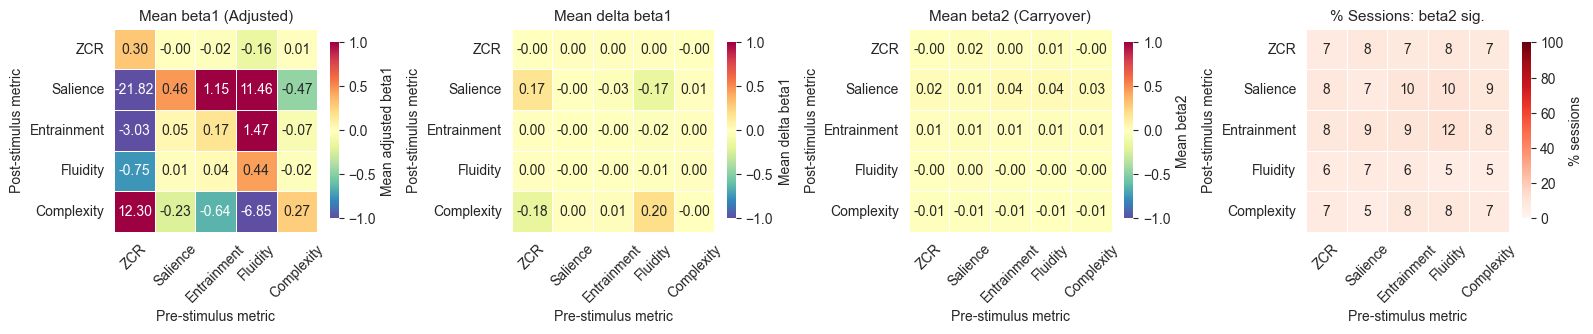

Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Supplementary_Carryover_control_5MOIs_SEEG.png
Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Supplementary_Carryover_control_5MOIs_SEEG.pdf


In [12]:
beta_abs_max = 1



fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))



heatmap_specs = [

    (mean_beta1_adj, 'Mean beta1 (Adjusted)', 'Spectral_r', -beta_abs_max, beta_abs_max, 'Mean adjusted beta1'),

    (mean_beta1_change, 'Mean delta beta1', 'Spectral_r', -beta_abs_max, beta_abs_max, 'Mean delta beta1'),

    (mean_beta2, 'Mean beta2 (Carryover)', 'Spectral_r', -beta_abs_max, beta_abs_max, 'Mean beta2'),

    (pct_beta2_sig, '% Sessions: beta2 sig.', 'Reds', 0, 100, '% sessions'),

]



for ax, (table, title, cmap, vmin, vmax, cbar_label) in zip(axes.flat, heatmap_specs):

    sns.heatmap(

        table,

        annot=True,

        fmt='.2f' if 'Mean' in title else '.0f',

        cmap=cmap,

        center=0 if cmap == 'Spectral_r' else None,

        vmin=vmin,

        vmax=vmax,

        cbar_kws={'label': cbar_label, 'shrink': 0.5},

        linewidths=0.5,

        square=True,

        ax=ax,

    )

    ax.set_title(title, fontsize=11)

    ax.set_xlabel('Pre-stimulus metric', fontsize=10)

    ax.set_ylabel('Post-stimulus metric', fontsize=10)

    ax.tick_params(axis='x', rotation=45)

    ax.tick_params(axis='y', rotation=0)



plt.tight_layout()

fig_path_png = results_fig_path / 'Supplementary_Carryover_control_5MOIs_SEEG.png'

#fig_path_pdf = results_fig_path / 'Supplementary_Carryover_control_5MOIs_SEEG.pdf'

plt.savefig(fig_path_png, dpi=300, bbox_inches='tight', transparent=True)

#plt.savefig(fig_path_pdf, dpi=300, bbox_inches='tight', transparent=True)

plt.show()



print(f'Saved figure: {fig_path_png}')

print(f'Saved figure: {fig_path_pdf}')

In [17]:
output_csv = metrics_root / 'df_carryover_control_5MOIs_SEEG.csv'
df_carryover.to_csv(output_csv, index=False)

summary_output = metrics_root / 'df_carryover_control_5MOIs_SEEG_summary_tables.xlsx'
summary_csv_dir = metrics_root / 'df_carryover_control_5MOIs_SEEG_summary_tables'
summary_csv_dir.mkdir(parents=True, exist_ok=True)

excel_saved = False
try:
    import openpyxl  # noqa: F401

    with pd.ExcelWriter(summary_output) as writer:
        for sheet_name, table in summary_tables.items():
            table.to_excel(writer, sheet_name=sheet_name[:31])
    excel_saved = True
except ModuleNotFoundError:
    for sheet_name, table in summary_tables.items():
        table.to_csv(summary_csv_dir / f'{sheet_name}.csv')
    print('openpyxl not installed; saved summary tables as CSV files instead of an Excel workbook.')

print(f'Saved session-level results: {output_csv}')
if excel_saved:
    print(f'Saved summary tables: {summary_output}')
else:
    print(f'Saved summary tables directory: {summary_csv_dir}')

openpyxl not installed; saved summary tables as CSV files instead of an Excel workbook.
Saved session-level results: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_carryover_control_5MOIs_SEEG.csv
Saved summary tables directory: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_carryover_control_5MOIs_SEEG_summary_tables


In [16]:
print('\n' + '=' * 100)
print('INTERPRETATION')
print('=' * 100)

msg = f"""
This supplementary analysis tests whether current-trial pre-to-post coupling can be explained by
carryover from the previous trial. Across the 5x5 metric-pair space in SEEG:

- Mean adjusted beta1 across all fits: {df_carryover['beta1_adj'].mean():.3f}
- Mean carryover beta2 across all fits: {df_carryover['beta2'].mean():.3f}
- Mean change in beta1 after adjustment: {df_carryover['beta1_change'].mean():.3f}
- Sessions with significant adjusted beta1: {(df_carryover['p1_adj'] < 0.05).mean() * 100:.1f}%
- Sessions with significant beta2 carryover: {(df_carryover['p2'] < 0.05).mean() * 100:.1f}%

Interpretation:
If beta1 remains present after adding previous-trial post as a covariate, then the main pre-to-post
relationship is not reducible to carryover. The heatmaps above allow this check for each metric pair.
Metric pairs with small delta beta1 and low beta2 significance provide the strongest evidence against
carryover-driven explanations.
"""
print(msg)


INTERPRETATION

This supplementary analysis tests whether current-trial pre-to-post coupling can be explained by
carryover from the previous trial. Across the 5x5 metric-pair space in SEEG:

- Mean adjusted beta1 across all fits: -0.237
- Mean carryover beta2 across all fits: 0.006
- Mean change in beta1 after adjustment: -0.001
- Sessions with significant adjusted beta1: 49.5%
- Sessions with significant beta2 carryover: 7.7%

Interpretation:
If beta1 remains present after adding previous-trial post as a covariate, then the main pre-to-post
relationship is not reducible to carryover. The heatmaps above allow this check for each metric pair.
Metric pairs with small delta beta1 and low beta2 significance provide the strongest evidence against
carryover-driven explanations.

